In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# read the veteran dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  Int64
 1   passanger             12684 non-null  Int64
 2   weather               12684 non-null  Int64
 3   temperature           12684 non-null  Int64
 4   time                  12684 non-null  Int64
 5   coupon                12684 non-null  Int64
 6   expiration            12684 non-null  Int64
 7   gender                12684 non-null  Int64
 8   age                   12684 non-null  Int64
 9   maritalStatus         12684 non-null  Int64
 10  has_children          12684 non-null  Int64
 11  education             12684 non-null  Int64
 12  occupation            12684 non-null  Int64
 13  income                12684 non-null  Int64
 14  Bar                   12684 non-null  Int64
 15  CoffeeHouse           12684 non-null  Int64
 16  Carr

In [3]:
# our goal is is_accepted
# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values
# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)
# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

In [4]:
from sklearn.model_selection import train_test_split
# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.2 # 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 10147
Size of testing set: 2537


In [5]:
## DT

from sklearn.feature_selection import RFECV


import pickle
from sklearn.feature_selection import SelectFromModel
with open('decision_tree_model.pickle', 'rb') as f:
    dt_best, roc_index_dt_cv, fpr_dt_cv, tpr_dt_cv = pickle.load(f)

    


In [6]:
print('*****Model parameters******\n', dt_best.get_params(deep=True))
print('Number of leaves in the trained model:', dt_best.get_n_leaves())

*****Model parameters******
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 15, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 10, 'splitter': 'best'}
Number of leaves in the trained model: 32


In [7]:
print("DT Testing set accuracy:", dt_best.score(X_test, y_test))

y_pred = dt_best.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

DT Testing set accuracy: 0.7004335829720142
              precision    recall  f1-score   support

           0       0.72      0.51      0.59      1095
           1       0.69      0.85      0.76      1442

    accuracy                           0.70      2537
   macro avg       0.70      0.68      0.68      2537
weighted avg       0.70      0.70      0.69      2537



In [8]:
# Reggression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
with open('LR.pickle', 'rb') as f:
     lr_best,roc_index_lr_best, fpr_lr_best, tpr_lr_best,scalerRM = pickle.load(f)
X_test_RM = scalerRM.transform(X_test)

In [9]:
print("RM Test accuracy:", lr_best.score(X_test_RM, y_test))

y_predRM = lr_best.predict(X_test_RM)
print(classification_report(y_test, y_predRM))

# print parameters of the best model
print(lr_best.best_params_)

RM Test accuracy: 0.6460386283011431
              precision    recall  f1-score   support

           0       0.62      0.46      0.53      1095
           1       0.66      0.79      0.72      1442

    accuracy                           0.65      2537
   macro avg       0.64      0.62      0.62      2537
weighted avg       0.64      0.65      0.64      2537

{'C': 0.1}


In [10]:
# Neural

with open('neural_network_model.pickle', 'rb') as f:
     cv_1,roc_index_cv_1, fpr_cv_1, tpr_cv_1, scalerNN = pickle.load(f)

In [11]:

random_seed = 10
#scaler80 = StandardScaler()
#X_train_sc = scaler.fit_transform(X_train, y_train)
X_test_sc = scalerNN.transform(X_test)

In [12]:
result_set = cv_1.cv_results_
print(result_set)

{'mean_fit_time': array([ 5.73533604,  8.41228235, 11.039763  , 18.33219986, 14.81377563]), 'std_fit_time': array([1.35391175, 1.07407362, 1.7008776 , 1.68015187, 1.91298074]), 'mean_score_time': array([0.00467982, 0.00266187, 0.00516424, 0.005494  , 0.00267334]), 'std_score_time': array([0.004469  , 0.00051958, 0.00597574, 0.00244086, 0.00082973]), 'param_hidden_layer_sizes': masked_array(data=[(5,), (25,), (45,), (65,), (85,)],
             mask=[False, False, False, False, False],
       fill_value='?',
            dtype=object), 'params': [{'hidden_layer_sizes': (5,)}, {'hidden_layer_sizes': (25,)}, {'hidden_layer_sizes': (45,)}, {'hidden_layer_sizes': (65,)}, {'hidden_layer_sizes': (85,)}], 'split0_test_score': array([0.67567568, 0.69932432, 0.67117117, 0.67004505, 0.68243243]), 'split1_test_score': array([0.63851351, 0.64301802, 0.68130631, 0.65202703, 0.65653153]), 'split2_test_score': array([0.67905405, 0.66216216, 0.68581081, 0.66441441, 0.67567568]), 'split3_test_score': arra

In [13]:

print("NN Test accuracy:", cv_1.score(X_test_sc, y_test))
y_pred = cv_1.predict(X_test_sc)
print(classification_report(y_test, y_pred))
print(cv_1.best_params_)

NN Test accuracy: 0.6897910918407568
              precision    recall  f1-score   support

           0       0.66      0.59      0.62      1095
           1       0.71      0.77      0.74      1442

    accuracy                           0.69      2537
   macro avg       0.68      0.68      0.68      2537
weighted avg       0.69      0.69      0.69      2537

{'hidden_layer_sizes': (45,)}


In [14]:
from sklearn.metrics import roc_auc_score
y_pred_proba_dt = dt_best.predict_proba(X_test)
y_pred_proba_RM = lr_best.predict_proba(X_test_RM)
y_pred_proba_NN = cv_1.predict_proba(X_test_sc)
roc_index_dt = roc_auc_score(y_test, y_pred_proba_dt[:, 1])
roc_index_RM = roc_auc_score(y_test, y_pred_proba_RM[:, 1])
roc_index_NN = roc_auc_score(y_test, y_pred_proba_NN[:, 1])
print("ROC index on test for DT:", roc_index_dt)
print("ROC index on test for RM:", roc_index_RM)
print("ROC index on test for NN:", roc_index_NN)

ROC index on test for DT: 0.7368713544734292
ROC index on test for RM: 0.6927216131831107
ROC index on test for NN: 0.7423881721860177


In [15]:
from sklearn.metrics import roc_curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt[:,1])
fpr_RM, tpr_RM, thresholds_RM = roc_curve(y_test, y_pred_proba_RM[:,1])
fpr_NN, tpr_NN, thresholds_NN = roc_curve(y_test, y_pred_proba_NN[:,1])

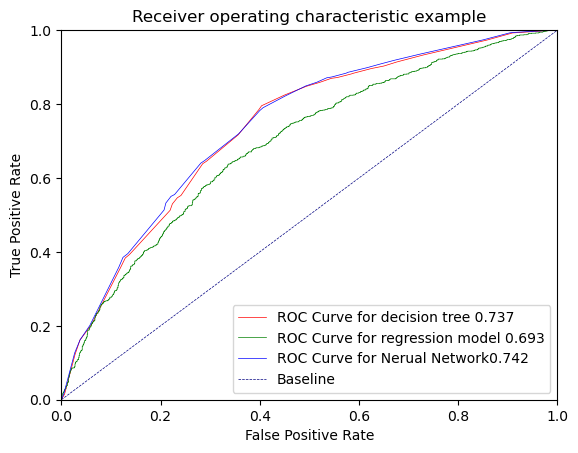

In [16]:
plt.plot(fpr_dt, tpr_dt, label='ROC Curve for decision tree {:.3f}'.format(roc_index_dt), color='red', lw=0.5)
plt.plot(fpr_RM, tpr_RM, label='ROC Curve for regression model {:.3f}'.format(roc_index_RM), color='green', lw=0.5)
plt.plot(fpr_dt_cv, tpr_dt_cv, label='ROC Curve for Nerual Network{:.3f}'.format(roc_index_NN), color='blue', lw=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=0.5, label='Baseline', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [18]:
print("DT Testing set accuracy:", dt_best.score(X_test, y_test))

y_pred = dt_best.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

print(60*"-")
print("RM Test accuracy:", lr_best.score(X_test_RM, y_test))

y_predRM = lr_best.predict(X_test_RM)
print(classification_report(y_test, y_predRM))

# print parameters of the best model
print(lr_best.best_params_)
print(60*"-")
print("NN Test accuracy:", cv_1.score(X_test_sc, y_test))
y_pred = cv_1.predict(X_test_sc)
print(classification_report(y_test, y_pred))
print(cv_1.best_params_)

DT Testing set accuracy: 0.7004335829720142
              precision    recall  f1-score   support

           0       0.72      0.51      0.59      1095
           1       0.69      0.85      0.76      1442

    accuracy                           0.70      2537
   macro avg       0.70      0.68      0.68      2537
weighted avg       0.70      0.70      0.69      2537

------------------------------------------------------------
RM Test accuracy: 0.6460386283011431
              precision    recall  f1-score   support

           0       0.62      0.46      0.53      1095
           1       0.66      0.79      0.72      1442

    accuracy                           0.65      2537
   macro avg       0.64      0.62      0.62      2537
weighted avg       0.64      0.65      0.64      2537

{'C': 0.1}
------------------------------------------------------------
NN Test accuracy: 0.6897910918407568
              precision    recall  f1-score   support

           0       0.66      0.59      0